# CIA: Controllable Image Augmentation

This notebook: captions images, generates synthetic versions using Stable Diffusion + ControlNet.

In [ ]:
!pip install ciagen

# needed for visualization of results
!pip install matplotlib pillow

## 1. Download sample images

In [6]:
import urllib.request
from pathlib import Path

INPUT_DIR = Path("input_images")
INPUT_DIR.mkdir(exist_ok=True)

sample_urls = [
    ("https://www.laborfinders.com/media/ce4gdtvi/women-in-construction.png", "samples001.png"),
    ("https://thehimalayantimes.com/uploads/imported_images/wp-content/uploads/2020/07/Kathmandu-movement.jpg", "samples002.png"),
    ("https://www.vlitefurnitech.com/wp-content/uploads/2024/11/View-of-cabin-office-scaled.webp", "samples003.png"),
]

for url, name in sample_urls:
    try:
        urllib.request.urlretrieve(url, INPUT_DIR / name)
        print(f"Downloaded: {name}")
    except Exception as e:
        print(f"Failed: {name} - {e}")

print(f"\nTotal images: {len(list(INPUT_DIR.glob('*')))}")

Downloaded: samples001.png
Downloaded: samples002.png
Downloaded: samples003.png

Total images: 4


## 2. Visualize source images

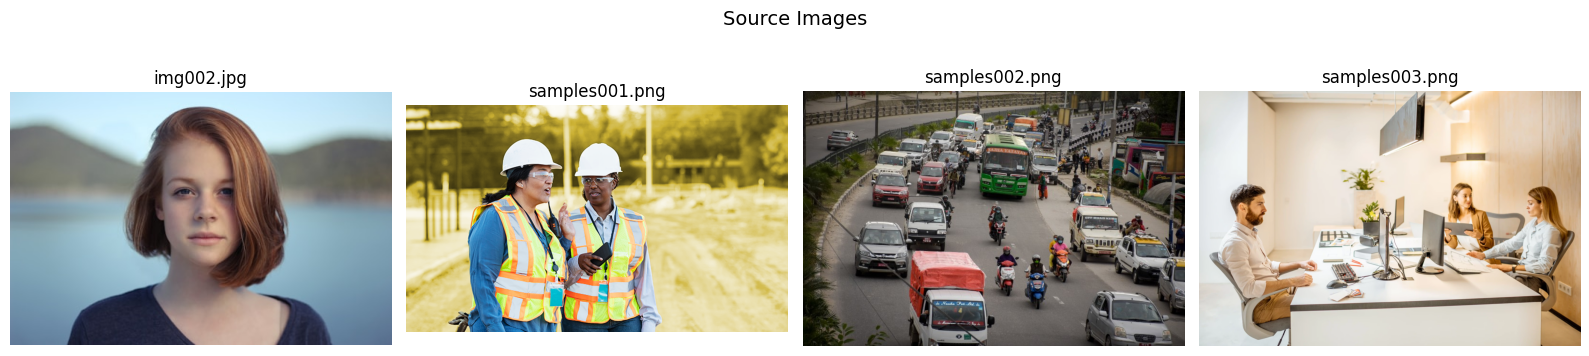

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

images = sorted(INPUT_DIR.glob("*"))
n = len(images)

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
if n == 1:
    axes = [axes]
for i, img_path in enumerate(images):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(img_path.name)
    axes[i].axis('off')
plt.suptitle("Source Images", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Configuration

In [ ]:
import os
from pathlib import Path

OUTPUT_DIR = Path("generated_images")
CAPTIONS_DIR = Path("captions")

OUTPUT_DIR.mkdir(exist_ok=True)
CAPTIONS_DIR.mkdir(exist_ok=True)

# API Key from https://openrouter.ai/keys
API_KEY = "<YOUR_API_KEY>"

print(f"Input: {INPUT_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Captions: {CAPTIONS_DIR}")
print(f"API Key: {'Set' if API_KEY else 'Not set'}")

Input: input_images
Output: generated_images
Captions: captions
API Key: Set


## 4. Caption images

In [9]:
import ciagen

if not API_KEY:
    print("ERROR: Set OPENROUTER_API_KEY first")
    print("Get free key: https://openrouter.ai/keys")
else:
    ciagen.caption(
        images=str(INPUT_DIR),
        captions_dir=str(CAPTIONS_DIR),
        engine="openrouter",
        model="google/gemini-2.0-flash-001",
        api_key=API_KEY,
    )
    print(f"Captions saved to {CAPTIONS_DIR}")
    # Show captions
    for cap_file in sorted(CAPTIONS_DIR.glob("*")):
        print(f"  {cap_file.stem}: {cap_file.read_text()[:80]}...")

Captioning images:   0%|          | 0/4 [00:00<?, ?it/s]

>>> USING MY DEBUG VERSION 3.0 <<<


Captioning images:  25%|██▌       | 1/4 [00:03<00:09,  3.16s/it]

OpenRouter status: 200
Response text (first 500): 
         

         

         

         

         

         
{"id":"gen-1777200862-nR3qoryjjJz8eEw6QroG","object":"chat.completion","created":1777200862,"model":"google/gemini-2.0-flash-001","provider":"Google","system_fingerprint":null,"choices":[{"index":0,"logprobs":null,"finish_reason":"stop","native_finish_reason":"STOP","message":{"role":"assistant","content":"The picture shows three people in a well-lit office space. A man is seated at a desk on the left, facing two women who are sea
>>> USING MY DEBUG VERSION 3.0 <<<


Captioning images:  50%|█████     | 2/4 [00:04<00:04,  2.36s/it]

OpenRouter status: 200
Response text (first 500): 
         

         

         

         
{"id":"gen-1777200865-hUS7F2K9gzSLL4hVoE5b","object":"chat.completion","created":1777200865,"model":"google/gemini-2.0-flash-001","provider":"Google AI Studio","system_fingerprint":null,"choices":[{"index":0,"logprobs":null,"finish_reason":"stop","native_finish_reason":"STOP","message":{"role":"assistant","content":"The picture shows two women standing outside, likely at a construction site. They are both wearing white hard hats, safety glasses, and hi
>>> USING MY DEBUG VERSION 3.0 <<<


Captioning images:  75%|███████▌  | 3/4 [00:06<00:02,  2.01s/it]

OpenRouter status: 200
Response text (first 500): 
         

         

         
{"id":"gen-1777200867-PVoXaV2SoN89ah4EajKh","object":"chat.completion","created":1777200867,"model":"google/gemini-2.0-flash-001","provider":"Google AI Studio","system_fingerprint":null,"choices":[{"index":0,"logprobs":null,"finish_reason":"stop","native_finish_reason":"STOP","message":{"role":"assistant","content":"The image shows a busy road filled with various types of vehicles, including cars, trucks, motorcycles, a bus (\"Sajha Yatayat\"), and vans. There al
>>> USING MY DEBUG VERSION 3.0 <<<


Captioning images: 100%|██████████| 4/4 [00:07<00:00,  1.93s/it]

OpenRouter status: 200
Response text (first 500): 
         

         
{"id":"gen-1777200868-zbVzciNSpqZTp56owXpI","object":"chat.completion","created":1777200868,"model":"google/gemini-2.0-flash-001","provider":"Google","system_fingerprint":null,"choices":[{"index":0,"logprobs":null,"finish_reason":"stop","native_finish_reason":"STOP","message":{"role":"assistant","content":"The picture contains a woman with red hair, a blurred background of water, and distant green hills. The woman is wearing either a V-neck or crew neck shirt and is looking
Captions saved to captions
  img002: The picture contains a woman with red hair, a blurred background of water, and d...
  samples001: The picture shows two women standing outside, likely at a construction site. The...
  samples002: The image shows a busy road filled with various types of vehicles, including car...
  samples003: The picture shows three people in a well-lit office space. A man is seated at a ...


## 5. Generate synthetic images

In [10]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

result = ciagen.generate(
    source=str(INPUT_DIR),
    output=str(OUTPUT_DIR),
    extractor="canny",
    sd_model="fennecinspace/sd-v15",
    cn_model="lllyasviel/sd-controlnet-canny",
    num_per_image=2,
    use_captions=True,
    captions_dir=str(CAPTIONS_DIR),
    seed=42,
    device=device,
)

print(f"\nGenerated {result['total_generated']} images")
print(f"Output: {result['output_path']}")

Using device: cuda


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  6.46it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
100%|██████████| 30/30 [02:00<00:00,  4.02s/it]



Generated 4 images
Output: generated_images


## 6. Visualize generated images

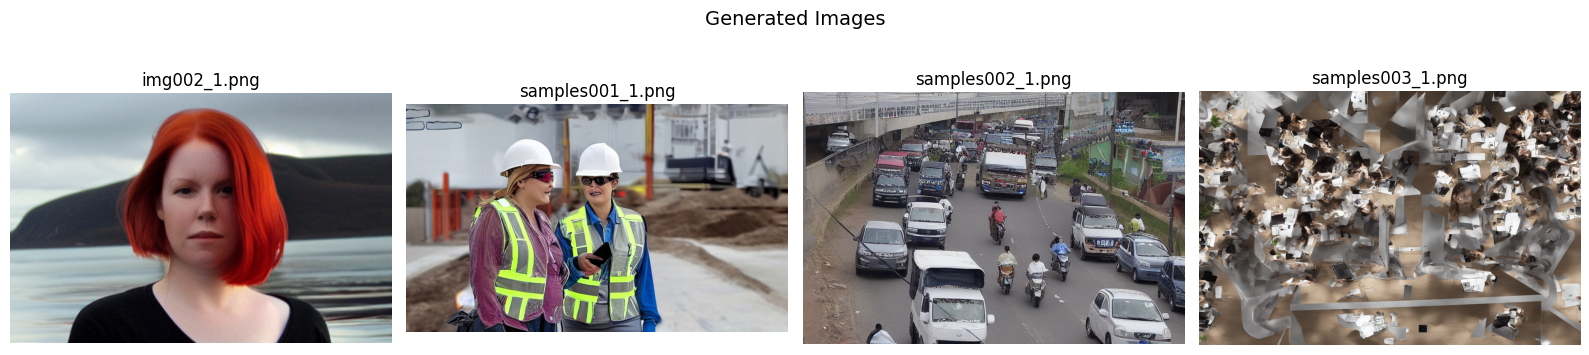

In [11]:
gen_images = sorted(OUTPUT_DIR.glob("*"))
n = len(gen_images)

fig, axes = plt.subplots(1, min(n, 6), figsize=(4*min(n,6), 4))
if n == 1:
    axes = [axes]
for i, img_path in enumerate(gen_images[:6]):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(img_path.name[:20])
    axes[i].axis('off')
plt.suptitle("Generated Images", fontsize=14)
plt.tight_layout()
plt.show()

## Done!